In [2]:
import scipy.stats as stats

In [7]:
def confidence_limits(observed_count, confidence_level): # confidence_level = 0.95
    alpha = 1 - confidence_level # alpha = 0.05
    lower_limit = stats.poisson.ppf(alpha / 2, observed_count) # ppf = percent point function
    upper_limit = stats.poisson.ppf(1 - alpha / 2, observed_count) # ppf = percent point function
    
    return lower_limit, upper_limit # return the lower and upper limits

In [8]:
assert confidence_limits(100, 0.68) == (90.0, 110.0) 
assert confidence_limits(100, 0.95) == (81.0, 120.0) 

In [9]:
import numpy as np
import math
import matplotlib.pyplot as plt
from iminuit import Minuit

In [17]:
def background(E_min, E_max, n_bins, B): # E_min = 0, E_max = 10, n_bins = 100, B = 10
    bin_edges = np.linspace(E_min, E_max, n_bins + 1) # Create n_bins + 1 edges
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2 # Compute bin centers
    bkg_counts = np.full(n_bins, B / n_bins) # Constant background
    
    return bin_centers, bkg_counts  # Constant background

In [11]:
E_min = 100 # Minimum energy
E_max = 300 # Maximum energy
n_bins = 40 # Number of bins
B = 2000 # Background counts


In [16]:
energies, bkg_counts = background(E_min, E_max, n_bins, B) # Compute background
assert len(energies) == n_bins # Check number of bins
assert math.isclose(np.sum(bkg_counts), B, abs_tol=1.0) # Check total background counts

In [23]:
def signal(E_min, E_max, n_bins, E_0, sigma, S): 
    bin_edges = np.linspace(E_min, E_max, n_bins + 1) # Create n_bins + 1 edges
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2 # Compute bin centers
    signal_counts = S * np.exp(-0.5 * ((bin_centers - E_0) / sigma) ** 2) # Gaussian signal
    signal_counts /= (sigma * np.sqrt(2 * np.pi)) # Normalize signal
    signal_counts *= (E_max - E_min) / n_bins # Normalize signal
    
    return bin_centers, signal_counts

In [19]:
E_0 = 250 
sigma = 10
S = 50

In [24]:
energies, signal_counts = signal(E_min, E_max, n_bins, E_0, sigma, S) # Compute signal
assert len(energies) == n_bins # Check number of bins
assert math.isclose(np.sum(signal_counts), S, abs_tol=0.1) # Check total signal counts

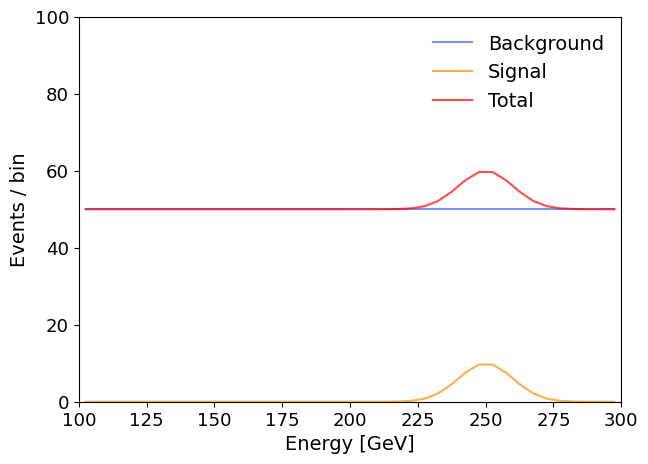

In [25]:
plt.figure(figsize=(7, 5)) # Create a new figure
plt.plot(energies, bkg_counts, alpha=0.7, color='royalblue', label='Background') # Plot background
plt.plot(energies, signal_counts, alpha=0.7, color='darkorange', label='Signal') #  Plot signal
plt.plot(energies, signal_counts+bkg_counts, alpha=0.7, color='red', label='Total')
plt.xlabel('Energy [GeV]', fontsize=14)
plt.ylabel('Events / bin', fontsize=14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(frameon=False, fontsize=14)
plt.xlim(100, 300)
plt.ylim(0, 100)
plt.show()

In [30]:

def generate_toy_mc(E_min, E_max, n_bins, E_0, sigma, S, B): 
    bin_edges = np.linspace(E_min, E_max, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = (E_max - E_min) / n_bins

    signal_counts = S * np.exp(-0.5 * ((bin_centers - E_0) / sigma) ** 2)
    signal_counts *= bin_width / (np.sqrt(2 * np.pi) * sigma)  # Normalize

    background_counts = np.full(n_bins, B / n_bins)

    signal_observed = np.random.poisson(signal_counts)
    background_observed = np.random.poisson(background_counts)

    toy_data = signal_observed + background_observed

    return toy_data

toy_mc_data = generate_toy_mc(E_min=0, E_max=10, n_bins=50, E_0=5, sigma=0.5, S=100, B=500)
toy_mc_data[:10]  


array([10, 11,  8,  5, 10, 11,  9, 10,  7,  5])

In [31]:
np.random.seed(42) # Set random seed for reproducibility

observed_counts = generate_toy_mc(E_min, E_max, n_bins, E_0, sigma, S, B) # Generate toy MC data
expected_counts = signal_counts+bkg_counts # Compute expected counts
assert observed_counts[-1] == 64 # Check last bin
assert np.sum(observed_counts) == 2087 # Check total counts

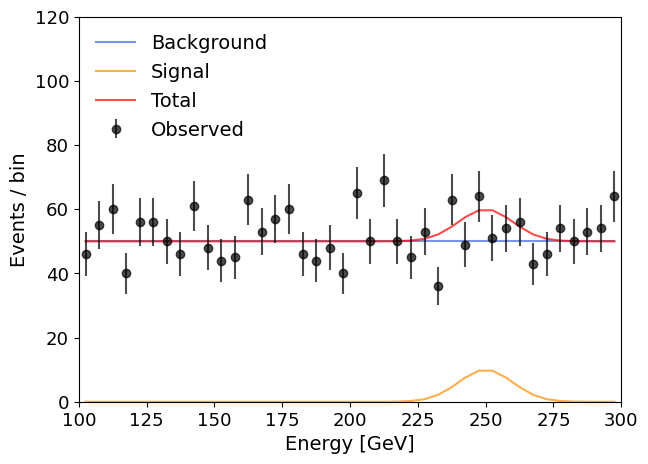

In [32]:
plt.figure(figsize=(7, 5)) 
plt.plot(energies, bkg_counts, alpha=0.7, color='royalblue', label='Background') # This Plots background
plt.plot(energies, signal_counts, alpha=0.7, color='darkorange', label='Signal') # Plots signal
plt.plot(energies, expected_counts, alpha=0.7, color='red', label='Total') # Plots total
plt.errorbar(energies, observed_counts, yerr=np.sqrt(observed_counts),  # Plots observed
             fmt='o', linestyle='None',
             alpha=0.7, color='black', label='Observed')
plt.xlabel('Energy [GeV]', fontsize=14) 
plt.ylabel('Events / bin', fontsize=14)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(loc='upper left', frameon=False, fontsize=14)
plt.xlim(100, 300)
plt.ylim(0, 120)
plt.show()

In [35]:
def chi2(S_fit, B_fit): # making use of the chi2 function
    _, signal_counts = signal(E_min, E_max, n_bins, E_0, sigma, S_fit)
    _, bkg_counts = background(E_min, E_max, n_bins, B_fit)
    expected_counts = signal_counts + bkg_counts
    chi2_value = np.sum((observed_counts - expected_counts) ** 2 / expected_counts)
    return chi2_value

S_init = 100 # Initial guess 
B_init = np.sum(observed_counts)

# Create a Minuit object with initial guesses for S_fit and B_fit
minuit = Minuit(chi2, S_fit=S_init, B_fit=B_init)
minuit.limits = [(0, None), (0, None)]
minuit.migrad()  # Minimization

best_fit_S = minuit.values["S_fit"]*2
best_fit_B = minuit.values["B_fit"]

print(f"Best-fit S: {best_fit_S:.2f}")
print(f"Best-fit B: {best_fit_B:.2f}")

chi2_min = minuit.fval

print(f"Best-fit chi-square: {chi2_min:.2f}")

Best-fit S: 31.99
Best-fit B: 2092.99
Best-fit chi-square: 44.14


In [36]:
chi2_test = chi2(50, 2000) 
assert math.isclose(chi2_test, 48.4744, abs_tol=1e-2) 

In [39]:
S_init = 100
B_init = np.sum(observed_counts)
minuit = Minuit(chi2, S_fit=S_init, B_fit=B_init)
minuit.limits = [(0, None), (0, None)]
minuit.migrad()  # Minimization

best_fit_S = minuit.values["S_fit"]
best_fit_B = minuit.values["B_fit"]

print(f"Best-fit S: {best_fit_S:.2f}")
print(f"Best-fit B: {best_fit_B:.2f}")

chi2_min = minuit.fval

print (f"Best-fit chi-square: {chi2_min:.2f}")

Best-fit S: 15.99
Best-fit B: 2092.99
Best-fit chi-square: 44.14


In [40]:
assert math.isclose(best_fit_S, 15.99, abs_tol=1e-2)
assert math.isclose(best_fit_B, 2092.99, abs_tol=1e-2)
assert math.isclose(chi2_min, 44.14, abs_tol=1e-2)

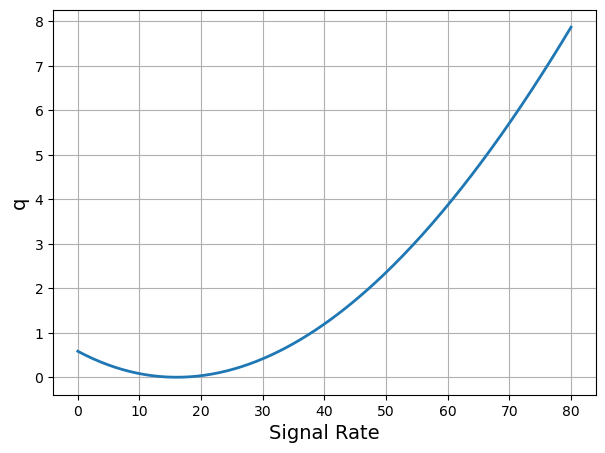

In [23]:
# I already have chi2_best_fit from the global best fit
# and have defined a function chi2(S_fit, B_fit) that returns chi2.

S_scan = np.linspace(0, 80, 200)  # Test range of signal strengths
q_values = [] # List to store q values

for s in S_scan: # Loop over signal strengths

    def chi2_fixed(B_fit):
        return chi2(s, B_fit)
    
    m_fixed = Minuit(chi2_fixed, B_fit=best_fit_B)  
    
    m_fixed.limits = [(0, None)]
    
    m_fixed.migrad()
    
    chi2_fixed = m_fixed.fval
    
    q = chi2_fixed - chi2_min
    q_values.append(q)

plt.figure(figsize=(7, 5))
plt.plot(S_scan, q_values, linewidth=2)
plt.xlabel("Signal Rate", fontsize=14)
plt.ylabel("q", fontsize=14)
plt.grid()
plt.show()


In [24]:
closest_diff = float('inf') # Initialize closest difference
closest_rate = float('inf') # Initialize closest rate 
for i in range(len(S_scan)): # Loop over signal strengths
    if abs(q_values[i]-2.71) < closest_diff and S_scan[i]>best_fit_S: # Check if closer to 2.71
        closest_diff = abs(q_values[i]-2.71) # Update closest difference
        closest_rate = S_scan[i]

In [25]:
print (f"Upper-limit on Signal Rate: {closest_rate:.2f}")
assert math.isclose(closest_rate, 52.66, abs_tol=1e-1)

Upper-limit on Signal Rate: 52.66


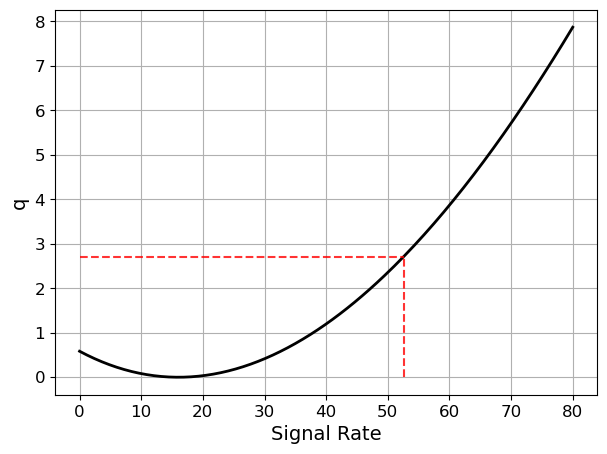

In [26]:
plt.figure(figsize=(7, 5))
plt.plot(S_scan, q_values, color='black', linewidth=2)
plt.hlines(2.71, 0, closest_rate, linestyle='--', color='red', alpha=0.8)
plt.vlines(closest_rate, 0, 2.71, linestyle='--', color='red', alpha=0.8)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel("Signal Rate", fontsize=14)
plt.ylabel("q", fontsize=14)
plt.grid()
plt.show()